# DNF Analysis

Documents the DNF modelling exploration and validates the crash+mechanical split approach against a no-DNF baseline.

**Note:** All earlier exploration results were invalidated by a lapped-finisher bug - FastF1 changed status format from `+1 Lap` to `Lapped` in 2023, causing lapped finishers to be classified as DNFs and scored -20pts. This notebook uses corrected data throughout.

**Shipped approach:** DNF risk captured via `rolling_crash_dnf_rate_last_5` and `constructor_rolling_mechanical_dnf_rate_last_5` as model features only. No compose-level DNF adjustment.

In [ ]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import fastf1

from app.config import (
    INTERIM_RACES_DIR, FANTASY_PRICES_DIR, PROCESSED_TARGETS_DIR,
    PROCESSED_HISTORIC_FEATURES_DIR, TRAIN_SEASONS, VAL_SEASONS, TEST_SEASONS, BUDGET_CAP
)
from app.models.configs import FINISH_POSITION_MODEL, QUALI_POSITION_MODEL
from app.models.predict import load_model, predict
from app.models.compose import compose_drivers, compose_constructor
from app.optimiser import optimiser
from app.models.backtest import get_actual_team_points

## DNF rate by type and season

In [2]:
race_results = pd.concat([pd.read_parquet(f) for f in sorted(INTERIM_RACES_DIR.glob('*.parquet'))])

by_season = race_results.groupby('season')[['dnf_flag', 'crash_dnf_flag', 'mechanical_dnf_flag']].mean()
by_season.columns = ['dnf_rate', 'crash_rate', 'mechanical_rate']
by_season['split'] = by_season.index.map(lambda s: 'train' if s in TRAIN_SEASONS else ('val' if s in VAL_SEASONS else 'test'))

print(by_season.to_string())

        dnf_rate  crash_rate  mechanical_rate  split
season                                              
2018    0.195238    0.073810         0.121429  train
2019    0.138095    0.061905         0.076190  train
2020    0.167647    0.067647         0.100000  train
2021    0.131818    0.068182         0.063636  train
2022    0.168182    0.072727         0.095455  train
2023    0.145455    0.077273         0.068182  train
2024    0.108559    0.052192         0.056367    val
2025    0.112735    0.068894         0.043841   test
2026    0.204545    0.045455         0.159091   test


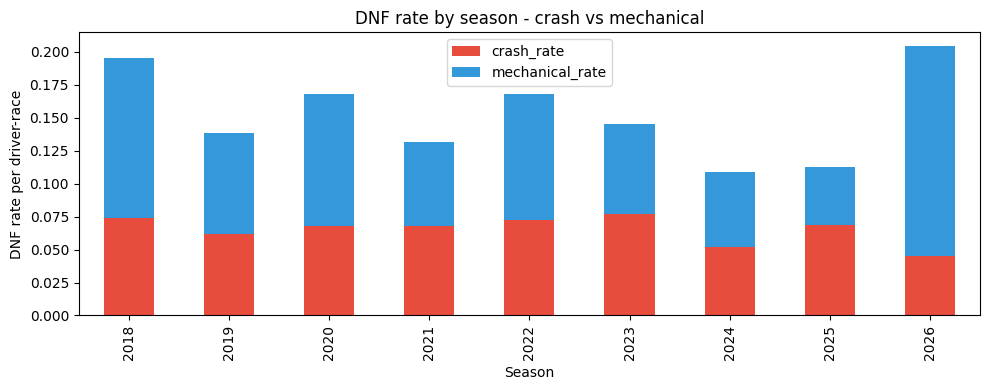

In [3]:
ax = by_season[['crash_rate', 'mechanical_rate']].plot(
    kind='bar', stacked=True, figsize=(10, 4),
    color=['#e74c3c', '#3498db'],
    title='DNF rate by season - crash vs mechanical'
)
ax.set_ylabel('DNF rate per driver-race')
ax.set_xlabel('Season')
plt.tight_layout()
plt.show()

## Why a trained DNF classifier fails - distribution shift

Trained XGBClassifier (AUC 0.507) failed because DNF rate differs significantly between train and val seasons. Rolling rate features avoid this by adapting to recent form rather than learning a global prior.

In [4]:
train = race_results[race_results['season'].isin(TRAIN_SEASONS)]
val = race_results[race_results['season'].isin(VAL_SEASONS)]

print('DNF rates by split (after lapped bug fix):')
print(f'  Train  - total: {train["dnf_flag"].mean():.3f} | crash: {train["crash_dnf_flag"].mean():.3f} | mechanical: {train["mechanical_dnf_flag"].mean():.3f}')
print(f'  Val    - total: {val["dnf_flag"].mean():.3f} | crash: {val["crash_dnf_flag"].mean():.3f} | mechanical: {val["mechanical_dnf_flag"].mean():.3f}')

DNF rates by split (after lapped bug fix):
  Train  - total: 0.157 | crash: 0.070 | mechanical: 0.087
  Val    - total: 0.109 | crash: 0.052 | mechanical: 0.056


## Constructor mechanical reliability

In [5]:
by_constructor = race_results.groupby('constructor_id')[['mechanical_dnf_flag', 'crash_dnf_flag']].mean()
by_constructor.columns = ['mechanical_rate', 'crash_rate']
by_constructor = by_constructor.sort_values('mechanical_rate', ascending=False)

print('Constructor DNF rates (all seasons):')
print(by_constructor.to_string())

Constructor DNF rates (all seasons):
                mechanical_rate  crash_rate
constructor_id                             
audi                   0.375000    0.000000
cadillac               0.125000    0.000000
renault                0.110169    0.076271
toro_rosso             0.107143    0.095238
racing_point           0.105263    0.065789
alphatauri             0.096386    0.066265
force_india            0.095238    0.071429
haas                   0.093220    0.076271
williams               0.090652    0.110482
aston_martin           0.089362    0.063830
alpine                 0.088983    0.059322
kick_sauber            0.086957    0.072464
alfa_romeo             0.076923    0.057692
red_bull               0.076271    0.059322
mclaren                0.070621    0.048023
ferrari                0.053672    0.067797
mercedes               0.042373    0.033898
racing_bulls           0.038462    0.105769


## Backtest comparison - no compose DNF vs crash+mechanical in compose

Compares two approaches on 2024 (val) and 2025 (test):
- **No DNF**: `dnf_prob = 0.0` - DNF risk handled entirely by model features
- **Crash+Mechanical**: `dnf_prob = rolling_crash_dnf_rate_last_5 + constructor_rolling_mechanical_dnf_rate_last_5` applied in `compose_drivers`

Key architectural decision: dnf_prob is applied directly to expected fantasy points in `compose_drivers`, not as a position adjustment - position to points is non-linear so position adjustments don't correctly scale expected points.

In [6]:
quali_model = load_model(QUALI_POSITION_MODEL)
finish_model = load_model(FINISH_POSITION_MODEL)

results = []

for s in VAL_SEASONS + TEST_SEASONS:
    schedule = fastf1.get_event_schedule(s)
    schedule = schedule[schedule['RoundNumber'] > 0]

    for round_num in schedule['RoundNumber']:
        prices_path = FANTASY_PRICES_DIR / f'{s}_{round_num:02d}.csv'
        features_path = PROCESSED_HISTORIC_FEATURES_DIR / f'{s}_{round_num:02d}.parquet'
        targets_path = PROCESSED_TARGETS_DIR / f'{s}_{round_num:02d}.parquet'

        if not (prices_path.exists() and features_path.exists() and targets_path.exists()):
            continue

        prices = pd.read_csv(prices_path)
        predictions = predict(quali_model, QUALI_POSITION_MODEL, finish_model, FINISH_POSITION_MODEL, s, round_num)
        feats = pd.read_parquet(features_path).set_index('driver_id')

        # no-DNF: model features only, no compose adjustment
        no_dnf_drivers = compose_drivers(predictions.copy())
        no_dnf_team = optimiser(no_dnf_drivers, compose_constructor(no_dnf_drivers), prices, BUDGET_CAP)
        no_dnf_pts = get_actual_team_points(no_dnf_team, s, round_num)

        # shrink_25: per-driver dnf_prob passed explicitly to compose
        crash = predictions['driver_id'].map(feats['rolling_crash_dnf_rate_last_5']).fillna(feats['rolling_crash_dnf_rate_last_5'].mean())
        mech = predictions['driver_id'].map(feats['constructor_rolling_mechanical_dnf_rate_last_5']).fillna(feats['constructor_rolling_mechanical_dnf_rate_last_5'].mean())
        dnf_prob = (crash + mech).values
        dnf_drivers = compose_drivers(predictions.copy(), dnf_prob=dnf_prob)
        dnf_team = optimiser(dnf_drivers, compose_constructor(dnf_drivers), prices, BUDGET_CAP)
        dnf_pts = get_actual_team_points(dnf_team, s, round_num)

        results.append({'season': s, 'round': round_num, 'no_dnf': no_dnf_pts, 'crash_mech': dnf_pts})
        print(f'{s} R{round_num:02d} - no_dnf: {no_dnf_pts:.0f} | crash_mech: {dnf_pts:.0f}')

df_results = pd.DataFrame(results)

req         WARNING 	DEFAULT CACHE ENABLED! (373.38 KB) C:\Users\gputs\AppData\Local\Temp\fastf1


2024 R01 - no_dnf: 120 | crash_mech: 176
2024 R02 - no_dnf: 163 | crash_mech: 124
2024 R03 - no_dnf: 67 | crash_mech: 51
2024 R04 - no_dnf: 111 | crash_mech: 90
2024 R05 - no_dnf: 117 | crash_mech: 138
2024 R06 - no_dnf: 127 | crash_mech: 131
2024 R07 - no_dnf: 149 | crash_mech: 150
2024 R08 - no_dnf: 98 | crash_mech: 182
2024 R09 - no_dnf: 139 | crash_mech: 139
2024 R10 - no_dnf: 122 | crash_mech: 129
2024 R11 - no_dnf: 167 | crash_mech: 167
2024 R12 - no_dnf: 168 | crash_mech: 168
2024 R13 - no_dnf: 119 | crash_mech: 137
2024 R14 - no_dnf: 26 | crash_mech: 102
2024 R15 - no_dnf: 136 | crash_mech: 119
2024 R16 - no_dnf: 147 | crash_mech: 175
2024 R17 - no_dnf: 110 | crash_mech: 110
2024 R18 - no_dnf: 64 | crash_mech: 87
2024 R19 - no_dnf: 97 | crash_mech: 101
2024 R20 - no_dnf: 102 | crash_mech: 94
2024 R21 - no_dnf: 63 | crash_mech: 97
2024 R22 - no_dnf: 129 | crash_mech: 87
2024 R23 - no_dnf: 77 | crash_mech: 109
2024 R24 - no_dnf: 45 | crash_mech: 13
2025 R01 - no_dnf: 124 | crash_

In [7]:
header = f'{"Season":<8} {"No DNF":>8} {"Crash+Mech":>12} {"Delta":>8}'
print()
print(header)
for s in VAL_SEASONS + TEST_SEASONS:
    sub = df_results[df_results["season"] == s]
    no_dnf = sub["no_dnf"].sum()
    crash_mech = sub["crash_mech"].sum()
    print(f"  {s}   {no_dnf:>8.0f} {crash_mech:>12.0f} {crash_mech - no_dnf:>+8.0f}")

no_dnf_total = df_results["no_dnf"].sum()
crash_mech_total = df_results["crash_mech"].sum()
print(f'  {"Total":<6} {no_dnf_total:>8.0f} {crash_mech_total:>12.0f} {crash_mech_total - no_dnf_total:>+8.0f}')


Season     No DNF   Crash+Mech    Delta
  2024       2663         2876     +213
  2025       3092         2995      -97
  Total      5755         5871     +116


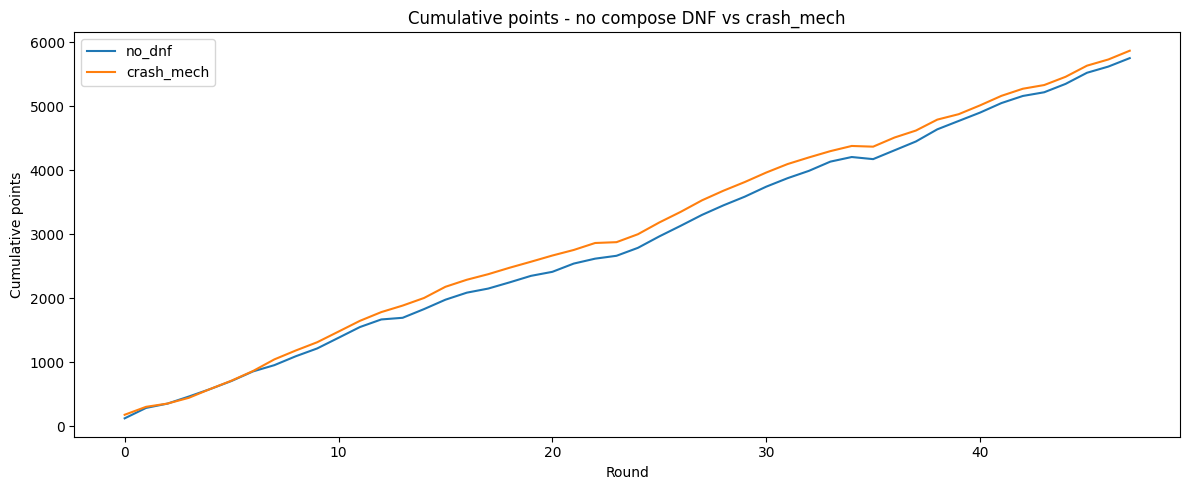

In [8]:
df_results[['no_dnf', 'crash_mech']].cumsum().plot(
    figsize=(12, 5),
    title='Cumulative points - no compose DNF vs crash_mech'
)
plt.xlabel('Round')
plt.ylabel('Cumulative points')
plt.tight_layout()
plt.show()

## Conclusion

Raw crash+mechanical in compose is inconsitent.

**Decision:** Drop compose-level DNF adjustment entirely. DNF risk is already captured via `rolling_crash_dnf_rate_last_5` and `constructor_rolling_mechanical_dnf_rate_last_5` as features in the finish position model - the model handles it implicitly without the chaos-race sensitivity of an explicit compose penalty.